پرسش 1. تشخیص تقلب در کارت‌های اعتباری با استفاده از شبکه‌های عصبی چندلایه

پیشپردازش و بررسی دادگان

In [ ]:
from google.colab import files
files.upload()

Saving archive.zip to archive.zip
Buffered data was truncated after reaching the output size limit.

In [ ]:
!unzip archive.zip

In [1]:
import pandas as pd
df=pd.read_csv("creditcard.csv")
original_columns=df.columns
print(df.shape)
df.head(10)

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


,count
Class,
0,284315
1,492


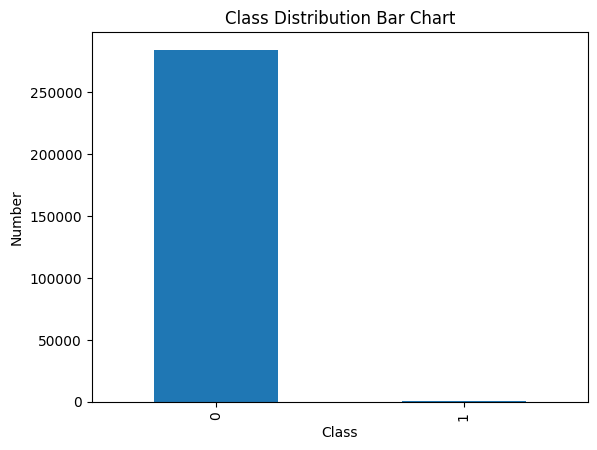

In [2]:
import matplotlib.pyplot as plt
import numpy as np
Class_counts=df['Class'].value_counts()
Class_counts.plot(kind='bar')
plt.xlabel("Class")
plt.ylabel("Number")
plt.title("Class Distribution Bar Chart")
Class_counts

In [3]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
df=pd.DataFrame(scaler.fit_transform(df),columns=original_columns)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.000000,0.935192,0.766490,0.881365,0.313023,0.763439,0.267669,0.266815,0.786444,0.475312,...,0.561184,0.522992,0.663793,0.391253,0.585122,0.394557,0.418976,0.312697,0.005824,0.0
1,0.000000,0.978542,0.770067,0.840298,0.271796,0.766120,0.262192,0.264875,0.786298,0.453981,...,0.557840,0.480237,0.666938,0.336440,0.587290,0.446013,0.416345,0.313423,0.000105,0.0
2,0.000006,0.935217,0.753118,0.868141,0.268766,0.762329,0.281122,0.270177,0.788042,0.410603,...,0.565477,0.546030,0.678939,0.289354,0.559515,0.402727,0.415489,0.311911,0.014739,0.0
3,0.000006,0.941878,0.765304,0.868484,0.213661,0.765647,0.275559,0.266803,0.789434,0.414999,...,0.559734,0.510277,0.662607,0.223826,0.614245,0.389197,0.417669,0.314371,0.004807,0.0
4,0.000012,0.938617,0.776520,0.864251,0.269796,0.762975,0.263984,0.268968,0.782484,0.490950,...,0.561327,0.547271,0.663392,0.401270,0.566343,0.507497,0.420561,0.317490,0.002724,0.0


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
target_column='Class'

df_majority = df[df[target_column] == 0]
df_minority = df[df[target_column] == 1]

df_majority_downsampled = resample(df_majority,replace=False
                                   ,n_samples=len(df_minority),random_state=42)

df_balanced = pd.concat([df_majority_downsampled,df_minority])
x=df_balanced.drop(target_column,axis=1)
y=df_balanced[[target_column]]
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,stratify=df_balanced[target_column], random_state=42)

print("Class distribution in Training Set:\n", y_train[target_column].value_counts(normalize=True))
print("\nClass distribution in Test Set:\n", y_test[target_column].value_counts(normalize=True))

Class distribution in Training Set:
 Class
1.0    0.5
0.0    0.5
Name: proportion, dtype: float64

Class distribution in Test Set:
 Class
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64


طراحی و پیاده سازی شبکه ساده ام ال پی

In [72]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

input_neurons=df.shape[1]-1
hidden_neurons=64
hidden_activation='relu'
use_dropout=False
dropout_rate=0.3
use_l2=False
lambda_l2=0.0001
output_neurons=1
output_activation='sigmoid'

In [73]:
model=keras.Sequential()

model.add(layers.Input(shape=(input_neurons,)))

if use_l2:
    model.add(layers.Dense(hidden_neurons, activation=hidden_activation,kernel_regularizer=regularizers.l2(lambda_l2)))
else:
    model.add(layers.Dense(hidden_neurons, activation=hidden_activation))

if use_dropout:
    model.add(layers.Dropout(dropout_rate))

model.add(layers.Dense(output_neurons, activation=output_activation))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                     │ (None, 64)                  │           1,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,049 (8.00 KB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6383 - loss: 0.6611
Epoch 2/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8116 - loss: 0.6246 
Epoch 3/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8135 - loss: 0.5894 
Epoch 4/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8713 - loss: 0.5647 
Epoch 5/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7925 - loss: 0.5231 
Epoch 6/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8638 - loss: 0.5023 
Epoch 7/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8756 - loss: 0.4716 
Epoch 8/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8858 - loss: 0.4408 
Epoch 9/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8849 - loss: 0.4153 
Epoch 10/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8704 - loss: 0.4160 
Epoch 11/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8863 - loss: 0.3780 
Epoch 12/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0

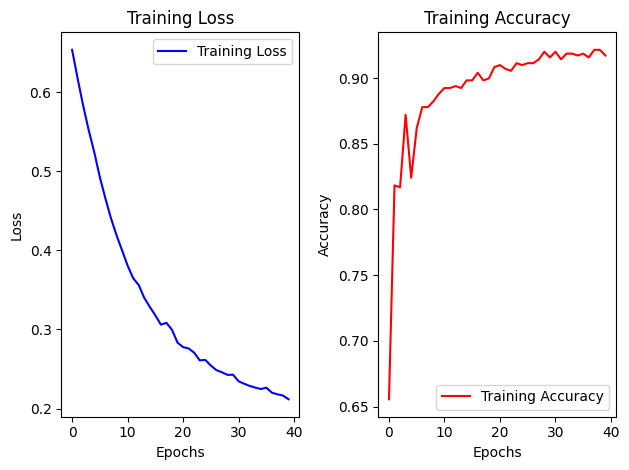

In [74]:
trained=model.fit(x_train, y_train, epochs=40, batch_size=32)
train_loss=trained.history['loss']
train_accuracy=trained.history['accuracy']

plt.subplot(1, 2, 1)
plt.plot(train_loss, 'b', label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, 'r', label='Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


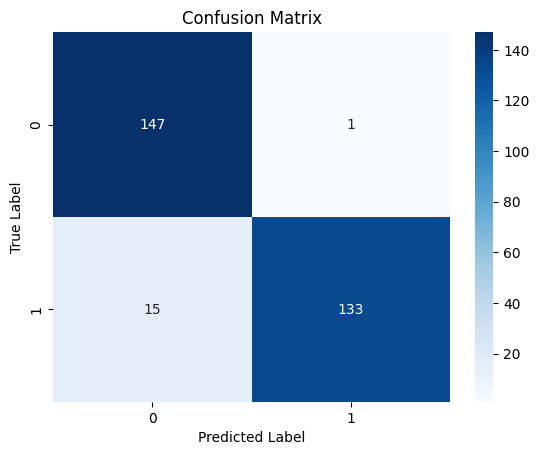

In [75]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
y_pred = model.predict(x_test)
y_pred = (y_pred > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [76]:
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

Accuracy: 0.9459
Precision: 0.9925
Recall: 0.8986
F1-Score: 0.9433


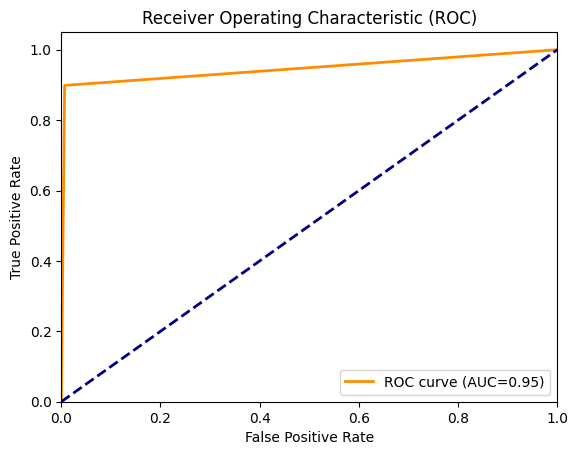

In [77]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC={roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [86]:
use_dropout=True
dropout_rate=0.3
use_l2=True
lambda_l2=0.0001

In [87]:
model=keras.Sequential()

model.add(layers.Input(shape=(input_neurons,)))

if use_l2:
    model.add(layers.Dense(hidden_neurons, activation=hidden_activation,kernel_regularizer=regularizers.l2(lambda_l2)))
else:
    model.add(layers.Dense(hidden_neurons, activation=hidden_activation))

if use_dropout:
    model.add(layers.Dropout(dropout_rate))

model.add(layers.Dense(output_neurons, activation=output_activation))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                     │ (None, 64)                  │           1,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,049 (8.00 KB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6153 - loss: 0.6652
Epoch 2/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6978 - loss: 0.6216 
Epoch 3/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7720 - loss: 0.5834 
Epoch 4/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8117 - loss: 0.5531 
Epoch 5/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7924 - loss: 0.5214 
Epoch 6/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8532 - loss: 0.4964 
Epoch 7/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8425 - loss: 0.4838 
Epoch 8/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8478 - loss: 0.4535 
Epoch 9/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8737 - loss: 0.4372 
Epoch 10/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8772 - loss: 0.4145 
Epoch 11/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8765 - loss: 0.4133 
Epoch 12/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0

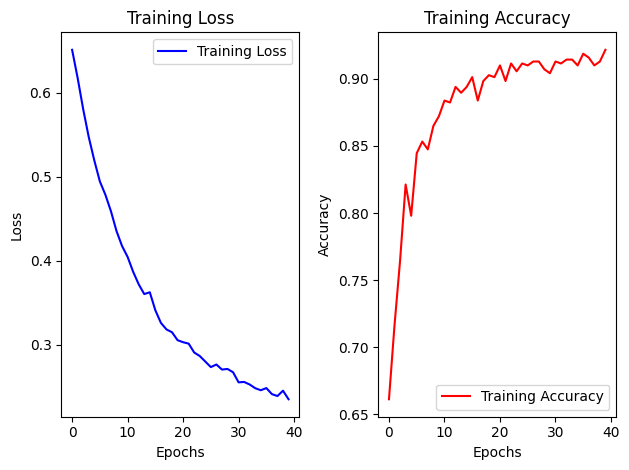

In [88]:
trained=model.fit(x_train, y_train, epochs=40, batch_size=32)
train_loss=trained.history['loss']
train_accuracy=trained.history['accuracy']

plt.subplot(1, 2, 1)
plt.plot(train_loss, 'b', label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, 'r', label='Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


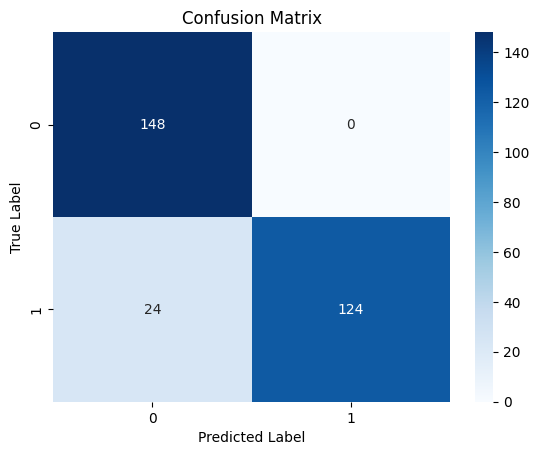

In [89]:
y_pred = model.predict(x_test)
y_pred = (y_pred > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [90]:
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

Accuracy: 0.9189
Precision: 1.0000
Recall: 0.8378
F1-Score: 0.9118


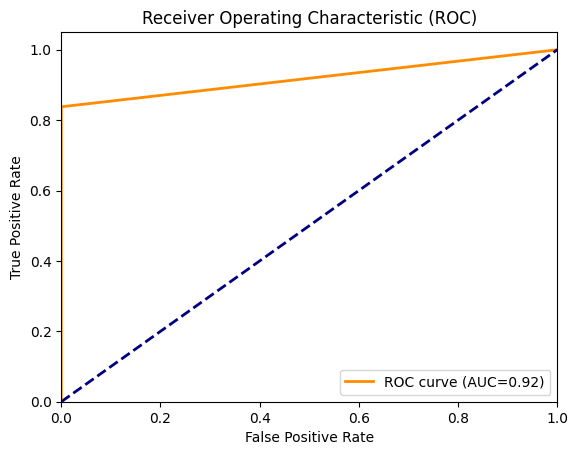

In [91]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC={roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

طراحي يك شبكه عميق تر

In [92]:
input_neurons=df.shape[1]-1
hidden_neurons_1=128
hidden_activation_1='relu'
hidden_neurons_2=64
hidden_activation_2='relu'
use_dropout=True
dropout_rate=0.2
use_l2=True
lambda_l2=0.0001
output_neurons=1
output_activation='sigmoid'

In [93]:
model=keras.Sequential()

model.add(layers.Input(shape=(input_neurons,)))

if use_l2:
    model.add(layers.Dense(hidden_neurons_1, activation=hidden_activation_1,kernel_regularizer=regularizers.l2(lambda_l2)))
    if use_dropout:
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(hidden_neurons_2, activation=hidden_activation_2,kernel_regularizer=regularizers.l2(lambda_l2)))
    if use_dropout:
        model.add(layers.Dropout(dropout_rate))
else:
    model.add(layers.Dense(hidden_neurons_1, activation=hidden_activation_1))
    if use_dropout:
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(hidden_neurons_2, activation=hidden_activation_2))
    if use_dropout:
        model.add(layers.Dropout(dropout_rate))

model.add(layers.Dense(output_neurons, activation=output_activation))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                     │ (None, 128)                 │           3,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5866 - loss: 0.6795
Epoch 2/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7700 - loss: 0.5877 
Epoch 3/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8546 - loss: 0.4885
Epoch 4/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8735 - loss: 0.3894 
Epoch 5/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8624 - loss: 0.3669 
Epoch 6/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8914 - loss: 0.3475 
Epoch 7/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9011 - loss: 0.2982 
Epoch 8/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9143 - loss: 0.2643 
Epoch 9/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9280 - loss: 0.2584 
Epoch 10/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9287 - loss: 0.2300 
Epoch 11/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9069 - loss: 0.2596
Epoch 12/40
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9

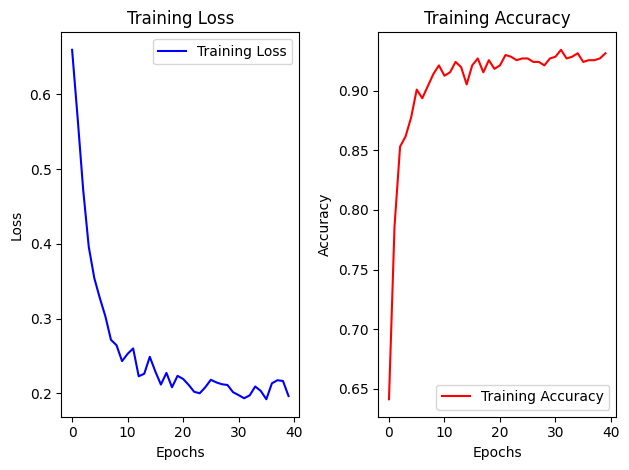

In [94]:
trained=model.fit(x_train, y_train, epochs=40, batch_size=32)
train_loss=trained.history['loss']
train_accuracy=trained.history['accuracy']

plt.subplot(1, 2, 1)
plt.plot(train_loss, 'b', label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, 'r', label='Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


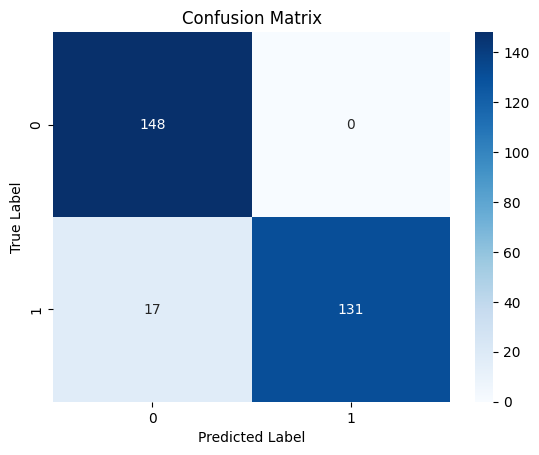

In [98]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
y_pred = model.predict(x_test)
y_pred = (y_pred > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [99]:
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

Accuracy: 0.9426
Precision: 1.0000
Recall: 0.8851
F1-Score: 0.9391


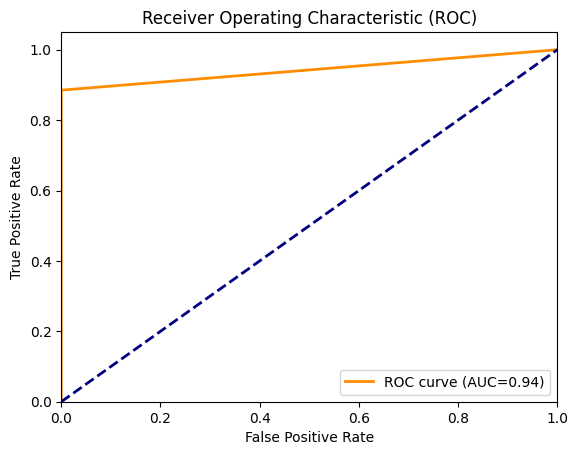

In [100]:
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC={roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [5]:
from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier
from keras.models import Sequential
from keras.layers import Input,Dense,Dropout
from keras.regularizers import l2

def create_model(input_neurons=20,neurons=32,dropout_rate=0.1,lambda_val=0.01,
                 output_neurons=1,output_activation='sigmoid'):
    model=Sequential([
        Input(shape=(input_neurons,)),
        Dense(neurons,activation='relu',kernel_regularizer=l2(lambda_val)),
        Dropout(dropout_rate),
        Dense(output_neurons,activation=output_activation)])

    model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
    return model


input_neurons=x_train.shape[1]
model=KerasClassifier(model=create_model,input_neurons=input_neurons,epochs=40,batch_size=32)
param_grid={
    'model__neurons':[64,128,256],
    'model__dropout_rate':[0.2,0.3,0.4],
    'model__lambda_val':[0.0001,0.001],
    'batch_size':[16,32,64]
}
grid=GridSearchCV(estimator=model,param_grid=param_grid,cv=3,n_jobs=1)
grid_result=grid.fit(x_train,y_train)
print(f"Best Accuracy: {grid_result.best_score_:.4f}")
print(f"Best Parameters: {grid_result.best_params_}")

Streaming output truncated to the last 5000 lines.
15/15 [==============================] - 0s 2ms/step - loss: 0.5326 - accuracy: 0.8170
Epoch 13/40
15/15 [==============================] - 0s 2ms/step - loss: 0.5148 - accuracy: 0.8257
Epoch 14/40
15/15 [==============================] - 0s 3ms/step - loss: 0.5015 - accuracy: 0.8431
Epoch 15/40
15/15 [==============================] - 0s 3ms/step - loss: 0.4794 - accuracy: 0.8736
Epoch 16/40
15/15 [==============================] - 0s 3ms/step - loss: 0.4673 - accuracy: 0.8649
Epoch 17/40
15/15 [==============================] - 0s 3ms/step - loss: 0.4583 - accuracy: 0.8693
Epoch 18/40
15/15 [==============================] - 0s 3ms/step - loss: 0.4567 - accuracy: 0.8584
Epoch 19/40
15/15 [==============================] - 0s 3ms/step - loss: 0.4403 - accuracy: 0.8606
Epoch 20/40
15/15 [==============================] - 0s 3ms/step - loss: 0.4273 - accuracy: 0.8824
Epoch 21/40
15/15 [==============================] - 0s 3ms/step - los

Epoch 1/40
43/43 [==============================] - 1s 2ms/step - loss: 0.6069 - accuracy: 0.7703
Epoch 2/40
43/43 [==============================] - 0s 2ms/step - loss: 0.4999 - accuracy: 0.8488
Epoch 3/40
43/43 [==============================] - 0s 2ms/step - loss: 0.4314 - accuracy: 0.8692
Epoch 4/40
43/43 [==============================] - 0s 2ms/step - loss: 0.3740 - accuracy: 0.8983
Epoch 5/40
43/43 [==============================] - 0s 2ms/step - loss: 0.3349 - accuracy: 0.9026
Epoch 6/40
43/43 [==============================] - 0s 2ms/step - loss: 0.3084 - accuracy: 0.9026
Epoch 7/40
43/43 [==============================] - 0s 2ms/step - loss: 0.2885 - accuracy: 0.9026
Epoch 8/40
43/43 [==============================] - 0s 2ms/step - loss: 0.2697 - accuracy: 0.9128
Epoch 9/40
43/43 [==============================] - 0s 2ms/step - loss: 0.2784 - accuracy: 0.9099
Epoch 10/40
43/43 [==============================] - 0s 2ms/step - loss: 0.2562 - accuracy: 0.9157
Epoch 11/40
43/43 [

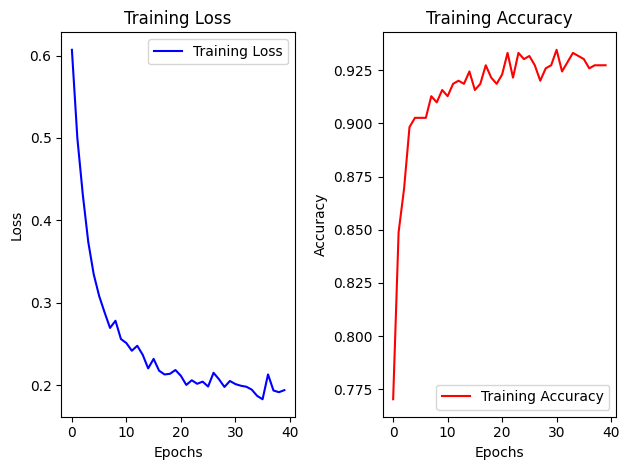

10/10 [==============================] - 0s 2ms/step


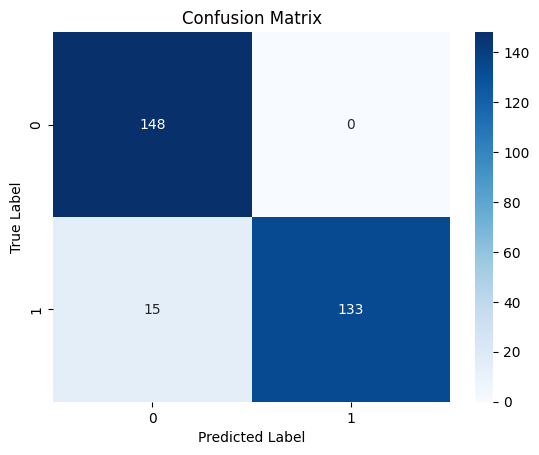

Accuracy: 0.9493
Precision: 1.0000
Recall: 0.8986
F1-Score: 0.9466


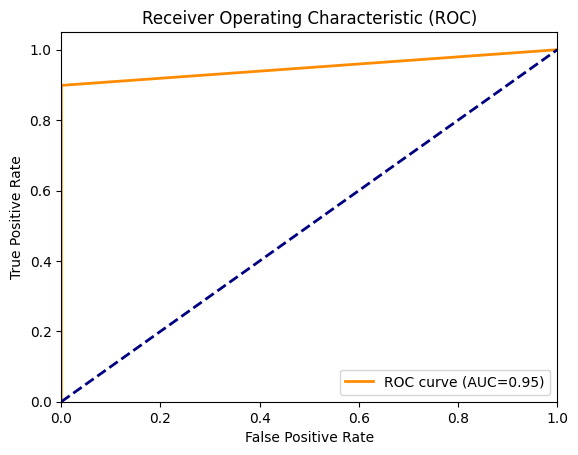

Model: "sequential_169"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_338 (Dense)           (None, 256)               7936      
                                                                 
 dropout_169 (Dropout)       (None, 256)               0         
                                                                 
 dense_339 (Dense)           (None, 1)                 257       
                                                                 
Total params: 8,193
Trainable params: 8,193
Non-trainable params: 0
_________________________________________________________________


In [15]:
best_model=create_model(
    input_neurons=input_neurons,
    neurons=grid_result.best_params_['model__neurons'],
    dropout_rate=grid_result.best_params_['model__dropout_rate'],
    lambda_val=grid_result.best_params_['model__lambda_val'])
trained=best_model.fit(x_train, y_train, epochs=40, batch_size=grid_result.best_params_['batch_size'])
train_loss=trained.history['loss']
train_accuracy=trained.history['accuracy']

plt.subplot(1, 2, 1)
plt.plot(train_loss, 'b', label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, 'r', label='Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.tight_layout()
plt.show()
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
y_pred = best_model.predict(x_test)
y_pred = (y_pred > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC={roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()
best_model.summary()

Logistic Regression

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1141: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


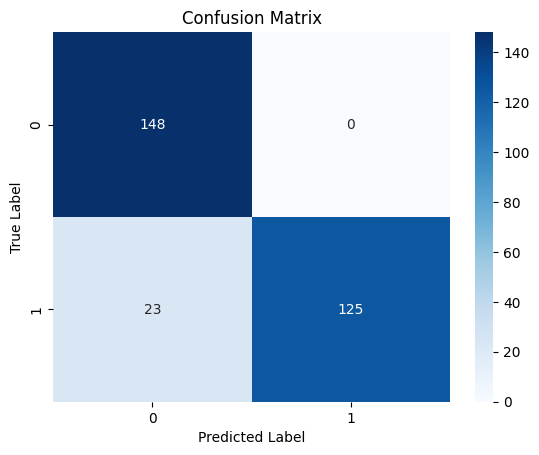

Accuracy: 0.9223
Precision: 1.0000
Recall: 0.8446
F1-Score: 0.9158


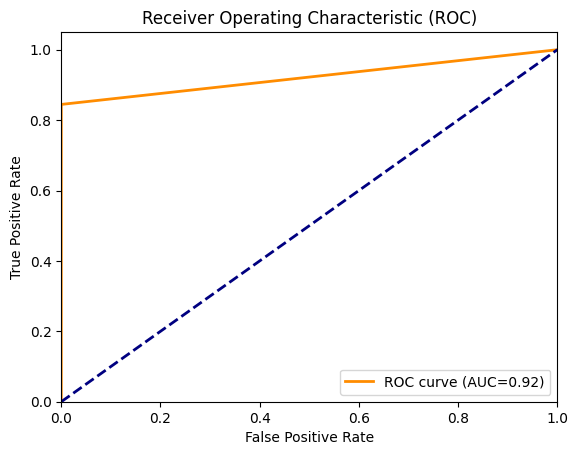

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.utils.validation import column_or_1d
model=LogisticRegression()
model.fit(x_train,y_train)
model.score(x_train,y_train)
y_pred=model.predict(x_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC={roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()